When you download or use it in Kaggle/Colab, you will see:
seg_train/
seg_test/
seg_pred/   (sometimes present)

1. Training Data → seg_train
This is your main dataset used to train the model.

Contains images in 6 categories:

i) buildings
ii) forest
iii) glacier
iv) mountain
v) sea
vi) street

Folder structure:
seg_train/
    buildings/
    forest/
    glacier/
    mountain/
    sea/
    street/

Each folder contains images of that class.

Purpose:
Used to teach the model
Model learns patterns (edges, shapes, textures)

2. Test Data → seg_test

This is NOT validation, but many students confuse it.

seg_test/
    buildings/
    forest/
    glacier/
    mountain/
    sea/
    street/

Purpose:
Used after training is complete
Measures final performance (accuracy)

3. Validation Data → ❗ NOT PROVIDED DIRECTLY

Important point 👇
👉 The dataset does NOT have a separate validation folder

So you must create validation data manually from seg_train

How to Create Validation Split

Typically:

80% → Training
20% → Validation

What This Code Does (Simple Understanding)
Reads images from:
seg_train/
   buildings/
   forest/
   glacier/
   mountain/
   sea/
   street/
Automatically:
Assigns labels (one-hot encoding)
Resizes images to 150×150
Splits into:
80% training
20% validation

In [1]:
# 1. Import Libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

2026-03-24 10:32:40.894466: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774348361.108153      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774348361.167208      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774348361.687059      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774348361.687107      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774348361.687110      24 computation_placer.cc:177] computation placer alr

In [2]:
# 2. Set Dataset Path
#train_dir = "/kaggle/input/intel-image-classification/seg_train/seg_train"
#test_dir= "/kaggle/input/intel-image-classification/seg_test/seg_test"
train_dir = "/kaggle/input/datasets/retreattechnology/assignment01deeplearning/Intel_Image_Classification_Dataset/seg_train"
test_dir = "/kaggle/input/datasets/retreattechnology/assignment01deeplearning/Intel_Image_Classification_Dataset/seg_test"


In [3]:
# 3. Data Preprocessing (Train + Validation Split)

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.


In [4]:
#4. Load Test Data
test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 3000 images belonging to 6 classes.


In [5]:
#5. Build CNN Model

model = models.Sequential()

# Block 1
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)))
model.add(layers.MaxPooling2D(2,2))

# Block 2
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

# Block 3
model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

# Flatten
model.add(layers.Flatten())

# Dense Layers
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))

# Output Layer (6 classes)
model.add(layers.Dense(6, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1774348401.721926      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774348401.728715      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [6]:
#6. Compile Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
# 7. Train Model
history = model.fit(
    train_data,
    epochs=10,
    validation_data=val_data
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1774348405.295799      91 service.cc:152] XLA service 0x7c2278002c70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774348405.295841      91 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774348405.295847      91 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774348405.695773      91 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/351 ━━━━━━━━━━━━━━━━━━━━ 35:37 6s/step - accuracy: 0.0625 - loss: 1.8140

I0000 00:00:1774348409.702030      91 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


351/351 ━━━━━━━━━━━━━━━━━━━━ 103s 276ms/step - accuracy: 0.4476 - loss: 1.4261 - val_accuracy: 0.6748 - val_loss: 0.8341
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 22s 62ms/step - accuracy: 0.6825 - loss: 0.8589 - val_accuracy: 0.7578 - val_loss: 0.6538
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 22s 63ms/step - accuracy: 0.7389 - loss: 0.7132 - val_accuracy: 0.7639 - val_loss: 0.6564
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 24s 70ms/step - accuracy: 0.7971 - loss: 0.5814 - val_accuracy: 0.7917 - val_loss: 0.5822
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 22s 64ms/step - accuracy: 0.8168 - loss: 0.5196 - val_accuracy: 0.8085 - val_loss: 0.5352
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 25s 70ms/step - accuracy: 0.8470 - loss: 0.4208 - val_accuracy: 0.8217 - val_loss: 0.5378
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.8678 - loss: 0.3764 - val_accuracy: 0.8263 - val_loss: 0.5224
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - accuracy: 0.8974 - loss: 0.2812 - val_accur

In [8]:
# 8. Evaluate on Test Data
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 22s 237ms/step - accuracy: 0.8296 - loss: 0.6409
Test Accuracy: 0.8389999866485596


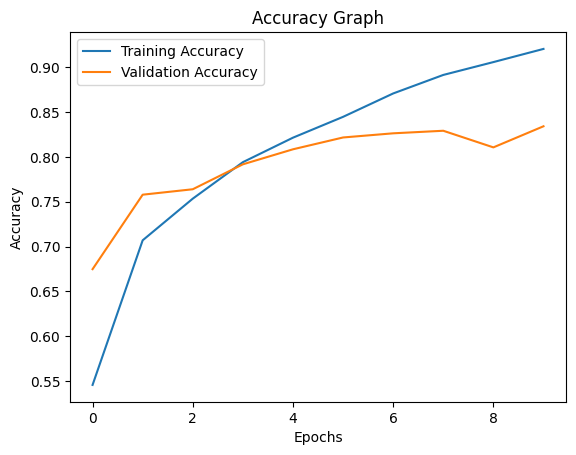

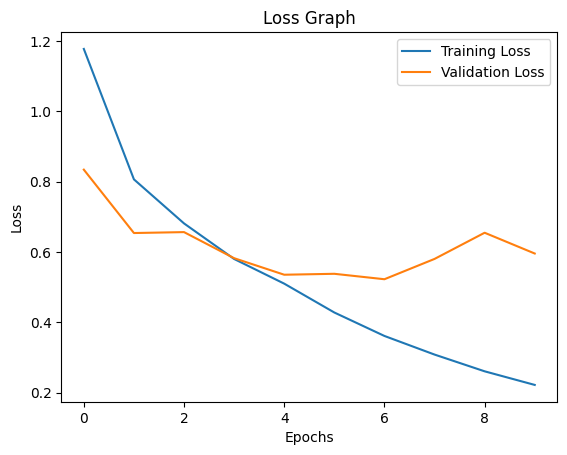

In [9]:
# 9. Accuracy & Loss Graphs
# Accuracy Plot
plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

# Loss Plot
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Graph")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

What you just built:
CNN with 3 convolution layers
ReLU activation
MaxPooling
Dropout (prevents overfitting)
Softmax output (6 classes)

Tips to Improve Accuracy

You can upgrade this model easily:

👉 Add data augmentation

ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

#👉 Increase epochs (20–30)
#👉 Use pretrained models (Transfer Learning like ResNet)

Final Understanding

Pipeline you implemented:

Dataset → Train Split → CNN → Validation → Test → Graphs